# Configuration

Task0: MNIST 0-4 

Task1: + MNIST 5

Task2: + MNIST 6

...

# Utils

In [2]:
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset, DataLoader, Subset, TensorDataset
from torchviz import make_dot
import os
import pandas as pd
import copy
import matplotlib.pyplot as plt
import copy
import seaborn as sns
import umap


from torch import nn, optim
import torch.nn.functional as F

import subprocess

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # For GPU determinism
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True  # Slower, but deterministic
    torch.backends.cudnn.benchmark = False     # Disable performance optimization

def create_dir_if_not_exists(path):
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"[INFO] Created directory: {path}")


def save_data(features, scores, labels, path):
    # scores = F.softmax(scores, dim=1)
    # data = np.concatenate((features.detach().cpu().numpy(), scores.detach().cpu().numpy()), axis=1)
    # df = pd.DataFrame(data)
    # df['label'] = labels.detach().cpu().numpy()
    # df.to_csv(path, index=False)
    # print(f"[INFO] Data saved to {path}")
    df = pd.DataFrame(features.numpy())
    scores_df = pd.DataFrame(scores.numpy())
    df = pd.concat([df, scores_df], axis=1)
    df['label'] = labels.numpy()
    df.to_csv(path, index=False)
    print(f"[INFO] Data saved to {path}")
    

def parse_digits(task_str):
    ranges = task_str.split(",")
    digits = []
    for r in ranges:
        if "-" in r:
            start, end = map(int, r.split("-"))
            digits.extend(range(start, end + 1))
        else:
            digits.append(int(r))
    return sorted(set(digits))

In [4]:
def load_mnist_task(digits, num_samples=None, is_train=True):
    """
    Load a MNIST dataset filtered by digits, optionally sample and update buffer.
    
    Args:
        digits: List of digits to include (e.g., [0, 1, 2, 3, 4])
        num_samples: If given, randomly sample this many from the filtered set
        buffer: A list (or set) to be updated with indices (global to full dataset)
        buffer_update_size: Number of samples from current digits to add to buffer
        is_train: Whether to load training or test data

    Returns:
        filtered_dataset: torch.utils.data.Subset of MNIST
        selected_indices: list of selected indices (relative to full dataset)
    """
    transform = transforms.ToTensor()
    mnist = datasets.MNIST("./data", train=is_train, download=True, transform=transform)

    # Filter by digits
    filtered_indices = [i for i, t in enumerate(mnist.targets) if t in digits]

    # Optional sampling
    if is_train and num_samples is not None and num_samples < len(filtered_indices):
        selected_indices = random.sample(filtered_indices, num_samples)
    else:
        selected_indices = filtered_indices
    
    # Get labels for selected indices
    selected_labels = mnist.targets[selected_indices]
    dataset = Subset(mnist, selected_indices)

    return dataset, selected_indices, selected_labels

# Global Config

In [5]:
# Global
seed = 42
root_folder = "500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)"
f_size = 64
# each task training config
train_batch_size = 128
test_batch_size = 128
epochs = 30


num_tasks = 6
global_task_labels = ["Task 0: 0-4", "Task 1: 5", "Task 2: 6", "Task 3: 7", "Task 4: 8", "Task 5: 9"]
tasks_epochs_accuracy = [[] for _ in range(num_tasks)] # list of lists (rows: tasks, cols: epochs)
tasks_epochs_accuracy_train = [[] for _ in range(num_tasks)]

global_num_epochs = 0
global_tsloaders = []
global_trloaders = []

# Model

In [6]:
device = torch.device("mps")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# --------- Model Definition ---------
class ConvFeatNet(nn.Module):
    def __init__(self, f_size = 64, num_classes = 10):
        super(ConvFeatNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 160)
        self.adapter = nn.Linear(160, f_size)
        self.fc2 = nn.Linear(f_size, 16)
        self.fc3 = nn.Linear(16, num_classes)
        

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        adapter_f = F.relu(self.adapter(x))
        x = F.relu(self.fc2(adapter_f))
        x = self.fc3(F.normalize(x, p=2, dim=1))
        return adapter_f, x
    
    def extract_adapter_features(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        adapter_f = F.relu(self.adapter(x))
        return adapter_f

    def forward_from_adapter(self, adapter_f):
        x = F.relu(self.fc2(adapter_f))
        x = self.fc3(F.normalize(x, p=2, dim=1))
        return x
    
# --------- Training and Evaluation ---------

def train(model, trloader, epochs, task_id, tsloaders, learning_rate=0.001, device='cpu'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)  
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        for batch_idx, (data, target) in enumerate(trloader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            _, output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
        
        acc = 100. * correct / total
        avg_loss = total_loss / len(trloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")
        
        # per epoch evaluation
        for task in range(num_tasks):
            if task <= task_id:
                tasks_epochs_accuracy_train[task].append(acc)
                test_acc = test(model, tsloaders[task], device=device)
                tasks_epochs_accuracy[task].append(test_acc)
            else:
                tasks_epochs_accuracy_train[task].append(np.nan)
                tasks_epochs_accuracy[task].append(np.nan)

def test(model, tsloader, device='cpu'):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for data, target in tsloader:
            data, target = data.to(device), target.to(device)
            _, output = model(data)
            loss = criterion(output, target)

            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(tsloader)
    print(f"Test: Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")
    return acc


def extract_adapter_features_and_labels(model, data_loader, device='cpu'):
    model.eval()
    features = []
    scores = []
    labels = []

    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            adapter_f = model.extract_adapter_features(data)
            out = model.forward_from_adapter(adapter_f)

            features.append(adapter_f.cpu())
            scores.append(out.cpu())
            labels.append(target.cpu())
    
    features = torch.cat(features, dim=0)
    scores = torch.cat(scores, dim=0)
    labels = torch.cat(labels, dim=0)

    return features, scores, labels


def train_from_adapter_features(model, trloader, task_id, tsloaders, epochs=10, learning_rate=0.001):
    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze fc2 and fc3 for training
    for param in model.fc2.parameters():
        param.requires_grad = True
    for param in model.fc3.parameters():
        param.requires_grad = True

    model.train()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for batch_idx, (adapter_f, target) in enumerate(trloader):
            adapter_f, target = adapter_f.to(device), target.to(device)  # adapter_f is input

            optimizer.zero_grad()
            output = model.forward_from_adapter(adapter_f)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

        acc = 100. * correct / total
        avg_loss = total_loss / len(trloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")

        # Evaluate per-task
        for task in range(num_tasks):
            if task <= task_id:
                acc_test = test(model, tsloaders[task], device=device)
                tasks_epochs_accuracy[task].append(acc_test)
                tasks_epochs_accuracy_train[task].append(acc)
            else:
                tasks_epochs_accuracy[task].append(np.nan)
                tasks_epochs_accuracy_train[task].append(np.nan)


def extract_from_adapter_features(model, dataloader, device='cpu'):
    """
    Given a dataloader that yields (adapter_features, labels),
    compute model scores and return (features, scores, labels).
    """
    model.eval()
    all_features = []
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for adapter_f, target in dataloader:
            adapter_f, target = adapter_f.to(device), target.to(device)

            output = model.forward_from_adapter(adapter_f)  # directly from adapter input

            all_features.append(adapter_f.cpu())  
            all_scores.append(output.cpu())       
            all_labels.append(target.cpu())

    features = torch.cat(all_features, dim=0)
    logits = torch.cat(all_scores, dim=0)
    labels = torch.cat(all_labels, dim=0)

    return features, logits, labels



device: mps


In [7]:
def compute_accuracy(scores, labels):
    preds = scores.argmax(dim=1)
    correct = (preds == labels).sum().item()
    acc = correct / len(labels)
    return acc

In [8]:
# model = ConvFeatNet(f_size=f_size)

# dummy_input = torch.randn(1, 1, 28, 28)

# # Perform a forward pass
# f, x = model(dummy_input)
# make_dot(x, params=dict(model.named_parameters())).render("convfeatnet_architecture", format="png")

# Task 0: MNIST class 0-4

In [9]:
task = '0-4'
train_batch_size = 128
test_batch_size = 128
epochs = 30

# Output dirs
parent_dir = os.getcwd()
parent_dir = os.path.join(parent_dir, root_folder)
task_dir = os.path.join(parent_dir, f'task{task}')
out_dir = os.path.join(task_dir, f'out/f{f_size}_task{task}')
model_dir = os.path.join(task_dir, f'model/f{f_size}_task{task}')
create_dir_if_not_exists(out_dir)
create_dir_if_not_exists(model_dir)

In [10]:
# Data
set_seed(seed)
digits = parse_digits(task)


train_set, _, train_labels = load_mnist_task(digits, is_train=True)
test_set, _, test_labels = load_mnist_task(digits, is_train=False)

print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))

print("Train class counts:", np.bincount(train_labels.numpy()))
print("Test class counts:", np.bincount(test_labels.numpy()))

trloader = DataLoader(train_set, batch_size=train_batch_size, shuffle=True)
tsloader = DataLoader(test_set, batch_size=test_batch_size, shuffle=False)

global_trloaders.append(trloader)
global_tsloaders.append(tsloader)

# Train MNIST
model = ConvFeatNet(f_size=f_size).to(device)
train(model, trloader, epochs=epochs, task_id=0, tsloaders=global_tsloaders, device=device)
torch.save(model.state_dict(), os.path.join(model_dir, f"MNIST_f{f_size}_task_{task}_net.pt"))
test(model, tsloader, device=device)


train_features, train_scores, train_labels = extract_adapter_features_and_labels(model, trloader, device=device)
test_features, test_scores, test_labels = extract_adapter_features_and_labels(model, tsloader, device=device)

print(f"Train features: {train_features.shape}, labels: {train_labels.shape}")
print(f"Test features: {test_features.shape}, labels: {test_labels.shape}")

train_acc = compute_accuracy(train_scores, train_labels)
test_acc = compute_accuracy(test_scores, test_labels)
print(f"Final Train Accuracy: {train_acc*100:.2f}%")
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# flatten featurens
save_data(train_features, train_scores, train_labels, os.path.join(out_dir, 'train_sftmx.csv'))
save_data(test_features, test_scores, test_labels, os.path.join(out_dir, 'test_sftmx.csv'))

global_num_epochs += epochs
print("\n[INFO] END")

Train set size:  30596
Test set size:  5139
Train class counts: [5923 6742 5958 6131 5842]
Test class counts: [ 980 1135 1032 1010  982]
Epoch [1/30], Loss: 1.5669, Accuracy: 84.82%
Test: Loss: 1.1179, Accuracy: 98.77%
Epoch [2/30], Loss: 0.8762, Accuracy: 97.89%
Test: Loss: 0.6490, Accuracy: 99.30%
Epoch [3/30], Loss: 0.5365, Accuracy: 98.27%
Test: Loss: 0.4100, Accuracy: 99.26%
Epoch [4/30], Loss: 0.3539, Accuracy: 98.61%
Test: Loss: 0.2737, Accuracy: 99.57%
Epoch [5/30], Loss: 0.2511, Accuracy: 98.76%
Test: Loss: 0.1990, Accuracy: 99.47%
Epoch [6/30], Loss: 0.1912, Accuracy: 98.77%
Test: Loss: 0.1475, Accuracy: 99.63%
Epoch [7/30], Loss: 0.1503, Accuracy: 98.88%
Test: Loss: 0.1151, Accuracy: 99.65%
Epoch [8/30], Loss: 0.1208, Accuracy: 99.04%
Test: Loss: 0.0918, Accuracy: 99.67%
Epoch [9/30], Loss: 0.1020, Accuracy: 99.09%
Test: Loss: 0.0759, Accuracy: 99.61%
Epoch [10/30], Loss: 0.0888, Accuracy: 98.98%
Test: Loss: 0.0617, Accuracy: 99.71%
Epoch [11/30], Loss: 0.0735, Accuracy: 99.

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
30


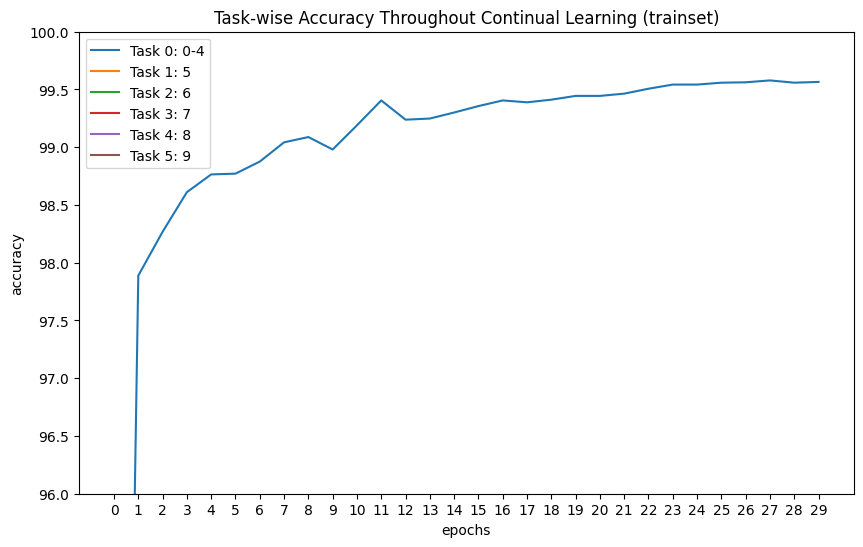

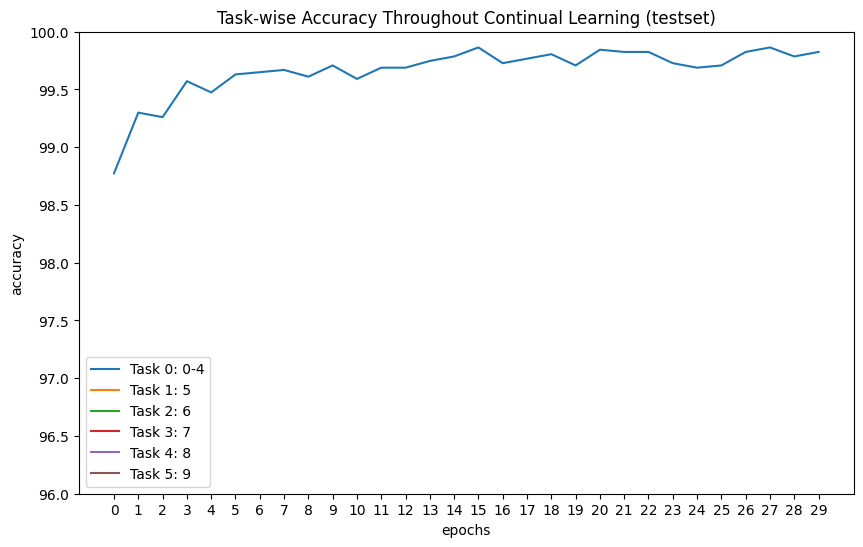

In [11]:
x = np.arange(global_num_epochs)
print(x)
print(len(tasks_epochs_accuracy[0]))

x = np.arange(global_num_epochs)

# Train set
plt.figure(figsize=(10, 6))
for task_id, accs in enumerate(tasks_epochs_accuracy_train):
    plt.plot(x, accs, label=global_task_labels[task_id])

plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Task-wise Accuracy Throughout Continual Learning (trainset)")
plt.legend()
plt.ylim(96, 100)
plt.xticks(np.arange(0, global_num_epochs, 1))
plt.show()

# Test set
plt.figure(figsize=(10, 6))
for task_id, accs in enumerate(tasks_epochs_accuracy):
    plt.plot(x, accs, label=global_task_labels[task_id])

plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Task-wise Accuracy Throughout Continual Learning (testset)")
plt.legend()
plt.ylim(96, 100)
plt.xticks(np.arange(0, global_num_epochs, 1))
plt.show()


In [12]:
df = pd.read_csv(os.path.join(out_dir, 'train_sftmx.csv'))
filtered_df = pd.DataFrame()

for i in range(1, 11):
    class_group = df[df['label'] == i-1]
    print(f"Class {i-1} size:", len(class_group))
    column_idx = f_size+i-1
    mean = class_group.iloc[:, column_idx].mean()
   
    lower_bound = class_group.iloc[:, column_idx].quantile(0.05)
    upper_bound = class_group.iloc[:, column_idx].quantile(0.95)
    print(f"  -> mean={mean:.5f}, lower={lower_bound:.5f}, upper={upper_bound:.5f}")

    filtered_class_group = class_group[
        (class_group.iloc[:, column_idx] >= lower_bound) &
        (class_group.iloc[:, column_idx] <= upper_bound)
    ]
    print(f"  -> kept: {len(filtered_class_group)} rows")
    save_path= os.path.join(out_dir, 'filtered_train_sftmx.csv')
    filtered_df = pd.concat([filtered_df, filtered_class_group])

filtered_df.to_csv(save_path, index=False)
print("Filtered Training Data")

Class 0 size: 5923
  -> mean=5.66188, lower=5.64342, upper=5.69032
  -> kept: 5330 rows
Class 1 size: 6742
  -> mean=5.63914, lower=5.58498, upper=5.67152
  -> kept: 6067 rows
Class 2 size: 5958
  -> mean=5.05200, lower=4.61157, upper=5.14826
  -> kept: 5362 rows
Class 3 size: 6131
  -> mean=6.05647, lower=5.99023, upper=6.09209
  -> kept: 5517 rows
Class 4 size: 5842
  -> mean=5.46956, lower=5.40525, upper=5.50881
  -> kept: 5256 rows
Class 5 size: 0
  -> mean=nan, lower=nan, upper=nan
  -> kept: 0 rows
Class 6 size: 0
  -> mean=nan, lower=nan, upper=nan
  -> kept: 0 rows
Class 7 size: 0
  -> mean=nan, lower=nan, upper=nan
  -> kept: 0 rows
Class 8 size: 0
  -> mean=nan, lower=nan, upper=nan
  -> kept: 0 rows
Class 9 size: 0
  -> mean=nan, lower=nan, upper=nan
  -> kept: 0 rows
Filtered Training Data


In [13]:
train_data_file = os.path.join(out_dir, 'filtered_train_sftmx.csv')
test_data_file = os.path.join(out_dir, 'test_sftmx.csv')

GP:

In [14]:

cmd = [
    "/usr/local/bin/Rscript",
    "train_GP.R",
    "-f", str(f_size),
    "--data_tr", train_data_file,
    "--data_ts", test_data_file,
    "--directory", task_dir,
    "--task", str(4)
]

subprocess.run(cmd)

Loading required package: Matrix

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

This is gplite version 0.13.0


Directory already exists: /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-4/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f64 
[1] "n is greater than the number of rows in the data frame, using all rows:1066"
[1] "class 0 training sample size (indclude noc_tr other classes): 1550"
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 9 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 118 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 129 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 61 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 130 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 381 is not positive>
[1] "validation MSE for class0: 4.39148685801729"
[1] 483  64
[1] "n is greater than the number of rows in the data fram

Warning messages:
1: In gp_optim(gp, x, y, tol = tol, tol_param = tol_param, maxiter = maxiter,  :
  Not all hyperparameters have reached convergence within tolerance tol_param = 0.100000. Try increasing the number of restarts, or reducing tol.
2: In gp_optim(gp, x, y, tol = tol, tol_param = tol_param, maxiter = maxiter,  :
  Not all hyperparameters have reached convergence within tolerance tol_param = 0.100000. Try increasing the number of restarts, or reducing tol.
3: In gp_optim(gp, x, y, tol = tol, tol_param = tol_param, maxiter = maxiter,  :
  Not all hyperparameters have reached convergence within tolerance tol_param = 0.100000. Try increasing the number of restarts, or reducing tol.


[1] "Total accuracy: 0.998054096127651"
[1] "Confusion Matrix for Class:0"
                   Actual_Positive Actual_Negative
Predicted_Positive             977               1
Predicted_Negative               3            4158
[1] "Accuracy: 0.99922163845106"
[1] "Precision: 0.998977505112474"
[1] "Recall for Class: 0.996938775510204"
[1] "F1 Score for Class: 0.997957099080695"
[1] "Confusion Matrix for Class:1"
                   Actual_Positive Actual_Negative
Predicted_Positive            1134               6
Predicted_Negative               1            3998
[1] "Accuracy: 0.998637867289356"
[1] "Precision: 0.994736842105263"
[1] "Recall for Class: 0.999118942731278"
[1] "F1 Score for Class: 0.996923076923077"
[1] "Confusion Matrix for Class:2"
                   Actual_Positive Actual_Negative
Predicted_Positive            1028               2
Predicted_Negative               4            4105
[1] "Accuracy: 0.998832457676591"
[1] "Precision: 0.998058252427184"
[1] "Recall for Cl

Warning messages:
1: Removed 574 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`). 
3: Removed 869 rows containing missing values or values outside the scale range
(`geom_line()`). 
4: Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`). 
5: Removed 567 rows containing missing values or values outside the scale range
(`geom_line()`). 
6: Removed 557 rows containing missing values or values outside the scale range
(`geom_line()`). 
7: Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`). 
8: Removed 392 rows containing missing values or values outside the scale range
(`geom_line()`). 


[1] "Save Results"
null device 
          1 


CompletedProcess(args=['/usr/local/bin/Rscript', 'train_GP.R', '-f', '64', '--data_tr', '/Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-4/out/f64_task0-4/filtered_train_sftmx.csv', '--data_ts', '/Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-4/out/f64_task0-4/test_sftmx.csv', '--directory', '/Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-4', '--task', '4'], returncode=0)

In [15]:
# save
tasks_epochs_accuracy_save = copy.deepcopy(tasks_epochs_accuracy)
tasks_epochs_accuracy_train_save = copy.deepcopy(tasks_epochs_accuracy_train)
global_num_epochs_save = global_num_epochs
global_tsloaders_save = global_tsloaders.copy()
global_trloaders_save = global_trloaders.copy()

# Task 1-5 Wrapper

In [16]:
def restore_prev_global_config():
    global tasks_epochs_accuracy
    global tasks_epochs_accuracy_train
    global global_num_epochs
    global global_tsloaders
    global global_trloaders
    
    tasks_epochs_accuracy = copy.deepcopy(tasks_epochs_accuracy_save)
    tasks_epochs_accuracy_train = copy.deepcopy(tasks_epochs_accuracy_train_save)

    global_num_epochs = global_num_epochs_save
    global_tsloaders = global_tsloaders_save.copy()
    global_trloaders = global_trloaders_save.copy()

In [17]:
def load_prev_model_and_create_current_dir(task_id, task, prev_task):
    """
        task_id = 0,1,2,3,4,5
        task = '0-(task_id+4)'
    """
    # previous_model_path = os.path.join(model_dir, f"MNIST_f{f_size}_task_{task}_net.pt")
    prev_model_sub_path = f"task{prev_task}/model/f{f_size}_task{prev_task}/MNIST_f{f_size}_task_{prev_task}_net.pt"
    previous_model_path = os.path.join(root_folder, prev_model_sub_path)
    print("Loading previous model from:", previous_model_path)

    # Output dirs
    parent_dir = os.getcwd()
    parent_dir = os.path.join(parent_dir, root_folder)
    task_dir = os.path.join(parent_dir, f'task{task}')
    out_dir = os.path.join(task_dir, f'out/f{f_size}_task{task}')
    model_dir = os.path.join(task_dir, f'model/f{f_size}_task{task}')
    create_dir_if_not_exists(out_dir)
    create_dir_if_not_exists(model_dir)

    return previous_model_path

In [18]:
def new_class_feature_space(task_id, task, previous_model_path):
    global global_tsloaders

    set_seed(seed)
    digits = parse_digits(task)
    task_d = task_id + 4
    # new_class_samples = 900 * (task_d -1) # change previouse class per class train size

    train_set, train_indices, train_labels = load_mnist_task(digits = [task_d], is_train=True)
    test_set, _, test_labels = load_mnist_task(digits = digits, is_train=False)

    trloader = DataLoader(train_set, batch_size=train_batch_size, shuffle=True)

    # print(len(test_set))
    # print(len(test_set[0]))
    # print(test_set[0][0].shape) # image

    tsloader = DataLoader(test_set, batch_size=test_batch_size, shuffle=False)
    global_tsloaders.append(tsloader)
    
    # Test Config
    print("Test set size: ", len(test_set))
    counts = np.bincount(test_labels.numpy())
    for cls, count in enumerate(counts):
        print(f"Class {cls}: {count} samples")
    
    # get new class feature space 
    model = ConvFeatNet(f_size=f_size).to(device)
    model.load_state_dict(torch.load(previous_model_path))
    model.eval()

    # new class feature space data
    newclass_data = torch.zeros(len(train_set), f_size+10+1)
    features, scores, labels = extract_adapter_features_and_labels(model, trloader, device=device)

    newclass_data[:, :f_size] = features
    newclass_data[:, f_size:f_size+10] = scores 
    newclass_data[:, -1] = labels
    print("Final new class feature space training dataset matrix size:", newclass_data.shape)
    return newclass_data, tsloader



In [19]:
def construct_prev_task_feature_train_set(prev_task, previous_model_path):
    """
        used only when not using GP inducing points
    """
    set_seed(seed)
    
    prev_digits = parse_digits(prev_task)
    num_samples = 1500 * len(prev_digits) # change previouse class per class train size
    print("planning to use ", num_samples, "samples from previous tasks")
    prev_train_set, _, _ = load_mnist_task(digits = prev_digits, num_samples= num_samples, is_train=True)

    prev_trloader = DataLoader(prev_train_set, batch_size=train_batch_size, shuffle=True)

    model = ConvFeatNet(f_size=f_size).to(device)
    model.load_state_dict(torch.load(previous_model_path))
    model.eval()

    # new class feature space data
    prevclass_data = torch.zeros(len(prev_train_set), f_size+10+1)
    features, scores, labels = extract_adapter_features_and_labels(model, prev_trloader, device=device)

    prevclass_data[:, :f_size] = features
    prevclass_data[:, f_size:f_size+10] = scores 
    prevclass_data[:, -1] = labels
    print("Final prev class feature space training dataset matrix size:", prevclass_data.shape)
    return prevclass_data



In [20]:
def generate_points_from_indcpts(indcpts_file_path, per_class_new_points = 100, output_file_path=None):
    indcpts_df = pd.read_csv(os.path.join(root_folder, indcpts_file_path), header=0)
    indcpts = indcpts_df.iloc[:, :-1].values  # Exclude labels
    labels = indcpts_df.iloc[:, -1].values  # Last column is labels
    unique_labels = np.unique(labels)
    new_points = [] 
    for label in unique_labels:
        label_points = indcpts[labels == label]
        # not separate X and Y, for convenience for later combining that cut off Y
        mean_point = np.mean(label_points, axis=0)
        std_point = np.std(label_points, axis=0)
        # print(mean_point.shape, std_point.shape)

        # Generate new points around the mean
        for _ in range(per_class_new_points):
            new_point = np.random.normal(loc=mean_point, scale=std_point)
            # add label
            new_point = np.append(new_point, label)
            new_points.append(new_point)
    
    # save to csv
    new_points = np.array(new_points)
    if output_file_path is not None:
        new_points_df = pd.DataFrame(new_points)
        new_points_df.to_csv(os.path.join(root_folder, output_file_path), index=False)
        print(f"[INFO] Generated points saved to {output_file_path}")


In [21]:
# print(root_folder)

In [22]:
# # test generate points
# generate_points_from_indcpts(
#     indcpts_file_path='task0-4/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f64/indcpts_pred_mat.csv',
#     per_class_new_points=100,
#     output_file_path='task0-4/indcpts_generated_points.csv'
# )

In [23]:
def concate_with_prev_data(indcpts_file_path, newclass_data, use_indcpts=True, prevclass_data = None, generated_points_path = None):
    global global_trloaders
    # previous_indcpts = pd.read_csv(os.path.join(root_folder, f"task0-4/RData/indpts_Rdata_ntr150000_nts50000_noctr200_f{f_size}/indcpts_pred_mat.csv"), header=0)
    if(use_indcpts):
        previous_indcpts = pd.read_csv(os.path.join(root_folder, indcpts_file_path), header=0)

        # print(previous_indcpts.dtypes)
        # previous_indcpts.head()
        previous_indcpts = torch.tensor(previous_indcpts.values, dtype=torch.float32)
        #### load generated points ####
        if generated_points_path is not None:
            generated_points = pd.read_csv(os.path.join(root_folder, generated_points_path), header=0)
            generated_points = torch.tensor(generated_points.values, dtype=torch.float32)
        else:
            print("Cannot find generated points path")

        fdim_dataset = torch.cat((newclass_data, previous_indcpts, generated_points), dim = 0)

        ### UMAP visualization
        umap_data = torch.cat((newclass_data, previous_indcpts), dim = 0)
        umap_X = umap_data[:, :f_size]
        umap_y = umap_data[:, -1]
        umap_reducer = umap.UMAP(n_components=2, random_state=42)
        X_2d = umap_reducer.fit_transform(umap_X)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=umap_y, palette='tab10', s=15, alpha=0.9)
        plt.title(f'UMAP Visualization of {f_size}d Feature Space \n (new class + previous inducing points)')
        plt.xlabel('UMAP-1')
        plt.ylabel('UMAP-2')
        plt.legend(title='Label')
        plt.show()
    else:
        fdim_dataset = torch.cat((newclass_data, prevclass_data), dim = 0)


    features = fdim_dataset[:, :f_size]
    labels = fdim_dataset[:, -1].long()

    fdim_train_set = TensorDataset(features, labels) # only select f_size | label columns
    train_loader = DataLoader(fdim_train_set, batch_size=train_batch_size, shuffle=True)
    
    global_trloaders.append(train_loader)
    # Train set Config
    print("Train set size: ", len(fdim_train_set))
    counts = np.bincount(labels.numpy())
    for cls, count in enumerate(counts):
        print(f"Class {cls}: {count} samples")

    print(len(fdim_train_set))
    print(len(fdim_train_set[0]))
    print(len(fdim_train_set[0][0]))
    print((fdim_train_set[0][1]))

    return train_loader


In [24]:
def train_newclass_task(train_loader, tsloader, task_id, task, previous_model_path, model_dir, epochs, out_dir):
    global global_num_epochs
    # Data
    set_seed(seed)

    # Train MNIST
    model = ConvFeatNet(f_size=f_size).to(device)
    model.load_state_dict(torch.load(previous_model_path))

    # only train after the adpative layer
    print("num_epochs: ", epochs)
    train_from_adapter_features(model=model, trloader=train_loader, task_id=task_id, tsloaders=global_tsloaders, epochs=epochs)
    torch.save(model.state_dict(), os.path.join(model_dir, f"MNIST_f{f_size}_task_{task}_net.pt"))

    train_features, train_scores, train_labels= extract_from_adapter_features(model, train_loader, device=device)
    test_features, test_scores, test_labels= extract_adapter_features_and_labels(model, tsloader, device=device) 

    train_acc = compute_accuracy(train_scores, train_labels)
    test_acc = compute_accuracy(test_scores, test_labels)
    print(f"Final Train Accuracy: {train_acc*100:.2f}%")
    print(f"Final Test Accuracy: {test_acc*100:.2f}%")

    save_data(train_features, train_scores, train_labels, os.path.join(out_dir, 'train_sftmx.csv'))
    save_data(test_features, test_scores, test_labels, os.path.join(out_dir, 'test_sftmx.csv'))

    global_num_epochs += epochs
    print("\n[INFO] END")


In [25]:
def plot_test_cl_curve():
    x = np.arange(global_num_epochs)
    # print(x)
    # print(len(tasks_epochs_accuracy[0]))

    # train set
    plt.figure(figsize=(10, 6))
    for task_id, accs in enumerate(tasks_epochs_accuracy_train):
        # print(len(x))
        # print(len(accs))
        plt.plot(x, accs, label=global_task_labels[task_id])

    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.tight_layout()
    plt.title("Task-wise Accuracy Throughout Continual Learning (trainset)")
    plt.legend()
    plt.xticks(np.arange(0, global_num_epochs, 5))
    plt.show()

    # test set
    plt.figure(figsize=(10, 6))
    for task_id, accs in enumerate(tasks_epochs_accuracy):
        # print(len(x))
        # print(len(accs))
        plt.plot(x, accs, label=global_task_labels[task_id])

    plt.xlabel("epochs")
    plt.tight_layout()
    plt.ylabel("accuracy")
    plt.title("Task-wise Accuracy Throughout Continual Learning (testset)")
    plt.legend()
    plt.xticks(np.arange(0, global_num_epochs, 5))
    plt.show()

In [26]:
def filter_train_data_for_GP(out_dir):
    df = pd.read_csv(os.path.join(out_dir, 'train_sftmx.csv'))
    filtered_df = pd.DataFrame()

    for i in range(1, 11):
        class_group = df[df['label'] == i-1]
        print(f"Class {i-1} size:", len(class_group))
        column_idx = f_size+i-1
        mean = class_group.iloc[:, column_idx].mean()
    
        lower_bound = class_group.iloc[:, column_idx].quantile(0.05)
        upper_bound = class_group.iloc[:, column_idx].quantile(0.95)
        print(f"  -> mean={mean:.5f}, lower={lower_bound:.5f}, upper={upper_bound:.5f}")

        filtered_class_group = class_group[
            (class_group.iloc[:, column_idx] >= lower_bound) &
            (class_group.iloc[:, column_idx] <= upper_bound)
        ]
        print(f"  -> kept: {len(filtered_class_group)} rows")
        save_path= os.path.join(out_dir, 'filtered_train_sftmx.csv')
        filtered_df = pd.concat([filtered_df, filtered_class_group])

    filtered_df.to_csv(save_path, index=False)
    print("Filtered Training Data")


In [27]:
def run_GP(out_dir, task_d, task_dir):
    train_data_file = os.path.join(out_dir, 'train_sftmx.csv')
    test_data_file = os.path.join(out_dir, 'test_sftmx.csv')

    print("Open task dir: ", task_dir)

    cmd = [
        "/usr/local/bin/Rscript",
        "train_GP.R",
        "-f", str(f_size),
        "--data_tr", train_data_file,
        "--data_ts", test_data_file,
        "--directory", task_dir,
        "--task", str(task_d)
    ]

    subprocess.run(cmd)

In [28]:
def run_task_i(task_id, task, prev_task, epochs=epochs, use_indcpts=True):
    task_d = task_id + 4
    indcpts_file_path = f"task{prev_task}/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f{f_size}/indcpts_pred_mat.csv" # ! change to target file !
    generated_points_path = f"task{prev_task}/indcpts_generated_points.csv" # ! change to target file !
    # Output dirs
    parent_dir = os.getcwd()
    parent_dir = os.path.join(parent_dir, root_folder)
    task_dir = os.path.join(parent_dir, f'task{task}')
    out_dir = os.path.join(task_dir, f'out/f{f_size}_task{task}')
    model_dir = os.path.join(task_dir, f'model/f{f_size}_task{task}')
    create_dir_if_not_exists(out_dir)
    create_dir_if_not_exists(model_dir)

    previous_model_path = load_prev_model_and_create_current_dir(task_id, task, prev_task)
    newclass_data, tsloader = new_class_feature_space(task_id, task, previous_model_path)
    
    if use_indcpts:
        generate_points_from_indcpts(indcpts_file_path, per_class_new_points=500, output_file_path=generated_points_path)
        train_loader = concate_with_prev_data(indcpts_file_path, newclass_data, use_indcpts, generated_points_path=generated_points_path)

    else:
        prevclass_data = construct_prev_task_feature_train_set(prev_task, previous_model_path)
        train_loader = concate_with_prev_data(indcpts_file_path, newclass_data, use_indcpts=False, prevclass_data=prevclass_data)
    print("run_task_i epochs:", epochs)
    train_newclass_task(train_loader, tsloader, task_id, task, previous_model_path, model_dir, epochs=epochs, out_dir=out_dir)
    plot_test_cl_curve()
    if use_indcpts:
        # filter_train_data_for_GP(out_dir)
        run_GP(out_dir, task_d, task_dir)
    
    print(f"------- Task {task_id} Finished -------")



# Task 1-5

## Task 1

In [29]:
# restore_prev_global_config()

Loading previous model from: 500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-4/model/f64_task0-4/MNIST_f64_task_0-4_net.pt
Test set size:  6031
Class 0: 980 samples
Class 1: 1135 samples
Class 2: 1032 samples
Class 3: 1010 samples
Class 4: 982 samples
Class 5: 892 samples


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/3322499310.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mod

Final new class feature space training dataset matrix size: torch.Size([5421, 75])
[INFO] Generated points saved to task0-4/indcpts_generated_points.csv


/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


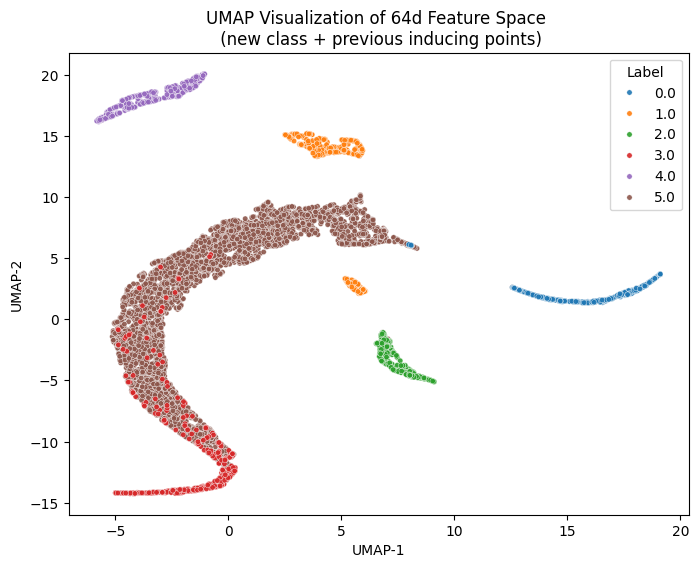

Train set size:  10336
Class 0: 983 samples
Class 1: 983 samples
Class 2: 983 samples
Class 3: 983 samples
Class 4: 983 samples
Class 5: 5421 samples
10336
2
64
tensor(5)
run_task_i epochs: 100
num_epochs:  100


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/1623880221.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mode

Epoch [1/100], Loss: 3.6457, Accuracy: 47.47%
Test: Loss: 0.2338, Accuracy: 98.99%
Test: Loss: 0.8921, Accuracy: 84.35%
Epoch [2/100], Loss: 2.2184, Accuracy: 47.52%
Test: Loss: 0.2249, Accuracy: 99.51%
Test: Loss: 0.7132, Accuracy: 84.80%
Epoch [3/100], Loss: 1.7612, Accuracy: 47.55%
Test: Loss: 0.2362, Accuracy: 99.57%
Test: Loss: 0.6200, Accuracy: 84.84%
Epoch [4/100], Loss: 1.4458, Accuracy: 47.55%
Test: Loss: 0.2332, Accuracy: 99.59%
Test: Loss: 0.5384, Accuracy: 84.86%
Epoch [5/100], Loss: 1.1868, Accuracy: 47.55%
Test: Loss: 0.2427, Accuracy: 99.51%
Test: Loss: 0.4786, Accuracy: 84.81%
Epoch [6/100], Loss: 0.9665, Accuracy: 60.87%
Test: Loss: 0.2419, Accuracy: 99.07%
Test: Loss: 0.4213, Accuracy: 91.86%
Epoch [7/100], Loss: 0.7846, Accuracy: 85.16%
Test: Loss: 0.2403, Accuracy: 97.20%
Test: Loss: 0.3755, Accuracy: 95.92%
Epoch [8/100], Loss: 0.6419, Accuracy: 95.95%
Test: Loss: 0.2538, Accuracy: 89.20%
Test: Loss: 0.3502, Accuracy: 90.71%
Epoch [9/100], Loss: 0.5311, Accuracy: 9

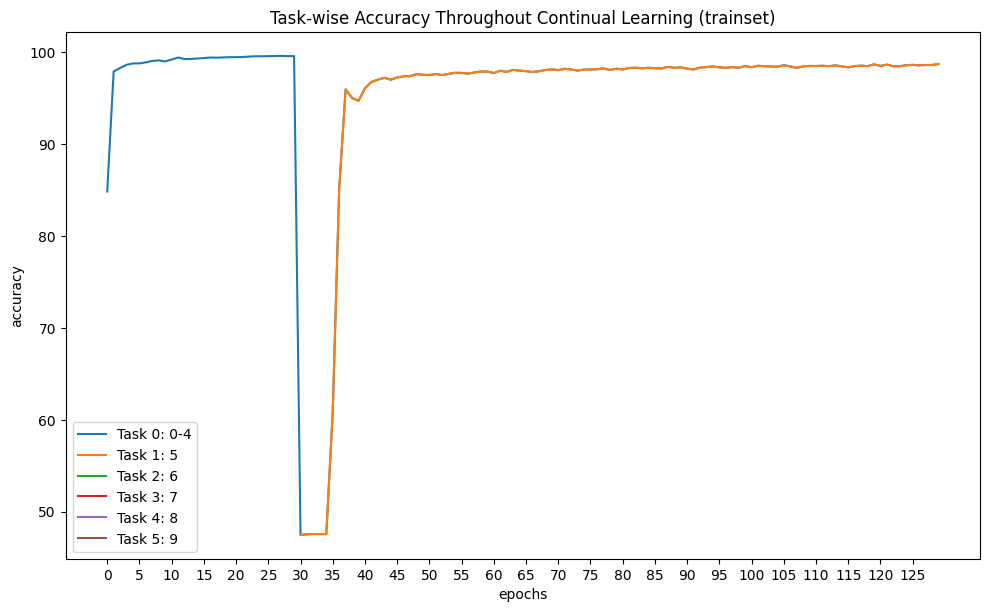

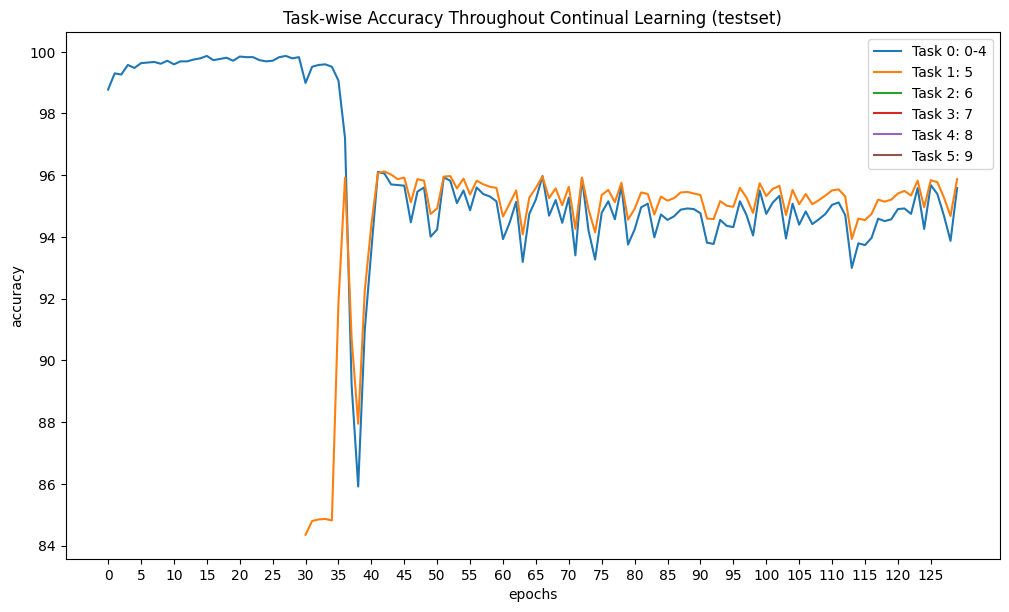

Open task dir:  /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-5


Loading required package: Matrix

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

This is gplite version 0.13.0


Directory already exists: /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-5/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f64 
[1] "n is greater than the number of rows in the data frame, using all rows:786"
[1] "n is greater than the number of rows in the data frame, using all rows:197"
[1] "class 0 training sample size (indclude noc_tr other classes): 836"
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 153 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 145 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 230 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 229 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 164 is not positive>
<simpleError in chol.default(K + V_inv_D_U): the leading minor of order 272 is not positive>
<simpleError in chol.default(K + V_inv

Warning messages:
1: Removed 296 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 427 rows containing missing values or values outside the scale range
(`geom_line()`). 
3: Removed 208 rows containing missing values or values outside the scale range
(`geom_line()`). 
4: Removed 558 rows containing missing values or values outside the scale range
(`geom_line()`). 


[1] "Save Results"
null device 
          1 
------- Task 1 Finished -------


In [30]:
run_task_i(task_id=1, task='0-5', prev_task='0-4', epochs=100, use_indcpts=True)

## Task 2

Loading previous model from: 500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-5/model/f64_task0-5/MNIST_f64_task_0-5_net.pt
Test set size:  6989
Class 0: 980 samples
Class 1: 1135 samples
Class 2: 1032 samples
Class 3: 1010 samples
Class 4: 982 samples
Class 5: 892 samples
Class 6: 958 samples


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/3322499310.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mod

Final new class feature space training dataset matrix size: torch.Size([5918, 75])
[INFO] Generated points saved to task0-5/indcpts_generated_points.csv


/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


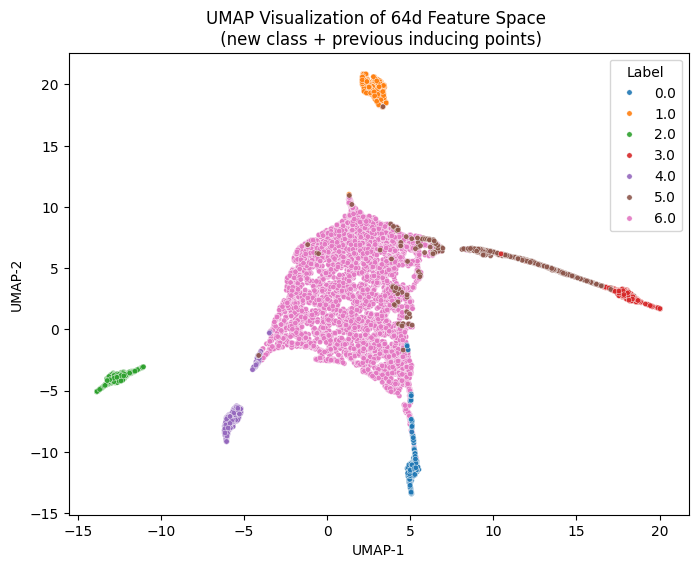

Train set size:  11751
Class 0: 969 samples
Class 1: 971 samples
Class 2: 971 samples
Class 3: 952 samples
Class 4: 970 samples
Class 5: 1000 samples
Class 6: 5918 samples
11751
2
64
tensor(6)
run_task_i epochs: 100
num_epochs:  100


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/1623880221.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mode

Epoch [1/100], Loss: 4.5262, Accuracy: 48.62%
Test: Loss: 0.1807, Accuracy: 95.47%
Test: Loss: 0.1840, Accuracy: 95.56%
Test: Loss: 1.1035, Accuracy: 82.46%
Epoch [2/100], Loss: 3.2277, Accuracy: 48.58%
Test: Loss: 0.1304, Accuracy: 96.30%
Test: Loss: 0.1498, Accuracy: 95.89%
Test: Loss: 0.9137, Accuracy: 82.74%
Epoch [3/100], Loss: 2.6134, Accuracy: 48.64%
Test: Loss: 0.1678, Accuracy: 97.18%
Test: Loss: 0.1913, Accuracy: 96.48%
Test: Loss: 0.7856, Accuracy: 83.26%
Epoch [4/100], Loss: 2.1921, Accuracy: 48.87%
Test: Loss: 0.1512, Accuracy: 96.91%
Test: Loss: 0.1702, Accuracy: 96.63%
Test: Loss: 0.6850, Accuracy: 83.39%
Epoch [5/100], Loss: 1.8900, Accuracy: 48.98%
Test: Loss: 0.1173, Accuracy: 97.80%
Test: Loss: 0.1563, Accuracy: 96.68%
Test: Loss: 0.5839, Accuracy: 83.43%
Epoch [6/100], Loss: 1.5039, Accuracy: 48.95%
Test: Loss: 0.1211, Accuracy: 97.90%
Test: Loss: 0.1661, Accuracy: 96.72%
Test: Loss: 0.4884, Accuracy: 83.46%
Epoch [7/100], Loss: 1.1927, Accuracy: 48.82%
Test: Loss: 

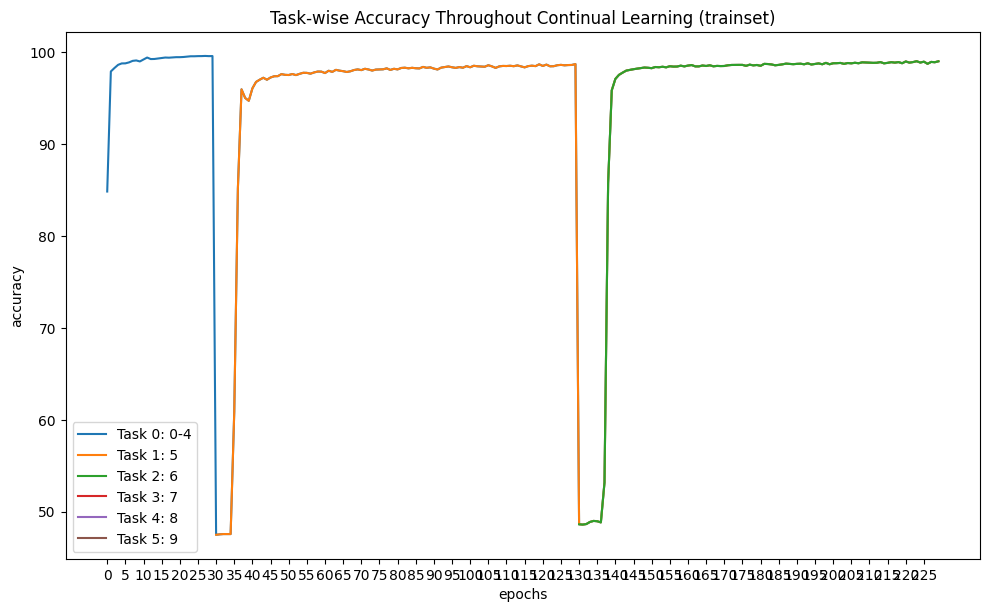

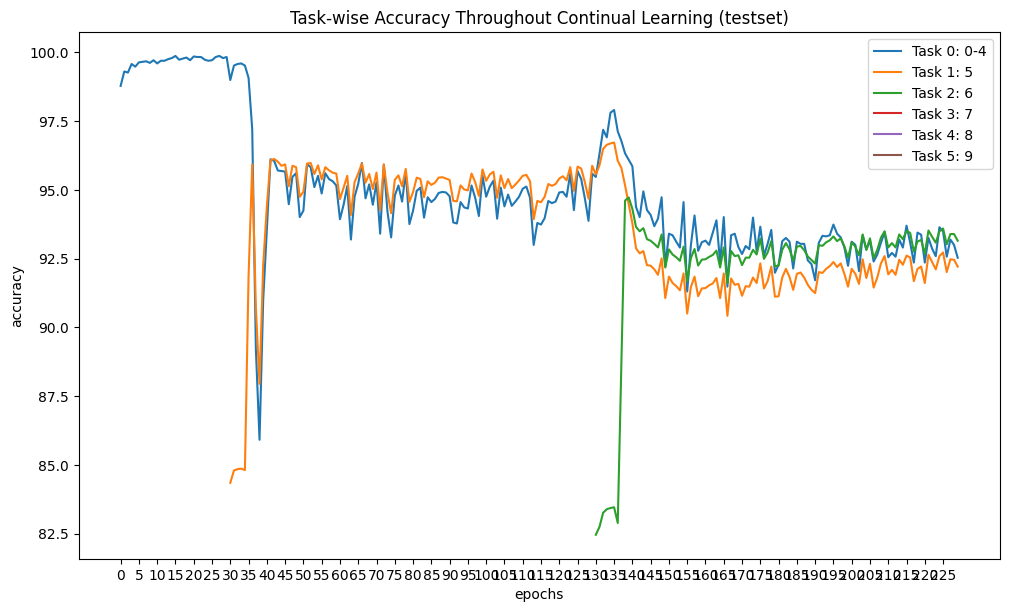

Open task dir:  /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-6


Loading required package: Matrix

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

This is gplite version 0.13.0


Directory already exists: /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-6/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f64 
[1] "n is greater than the number of rows in the data frame, using all rows:775"
[1] "n is greater than the number of rows in the data frame, using all rows:194"
[1] "class 0 training sample size (indclude noc_tr other classes): 825"
[1] "validation MSE for class0: 11.0150164724471"
[1] 469  64
[1] "n is greater than the number of rows in the data frame, using all rows:776"
[1] "n is greater than the number of rows in the data frame, using all rows:195"
[1] "class 1 training sample size (indclude noc_tr other classes): 826"
[1] "validation MSE for class1: 27.1806436165651"
[1] 938  64
[1] "n is greater than the number of rows in the data frame, using all rows:776"
[1] "n is greater than the number of rows in the data frame, using all rows:195"
[1] "class 2 training sample size (indclude noc_tr other classes): 826"
[1] 

Warning messages:
1: Removed 500 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 359 rows containing missing values or values outside the scale range
(`geom_line()`). 
3: Removed 17 rows containing missing values or values outside the scale range
(`geom_line()`). 
4: Removed 234 rows containing missing values or values outside the scale range
(`geom_line()`). 
5: Removed 259 rows containing missing values or values outside the scale range
(`geom_line()`). 
6: Removed 552 rows containing missing values or values outside the scale range
(`geom_line()`). 
7: Removed 648 rows containing missing values or values outside the scale range
(`geom_line()`). 


[1] "Save Results"
null device 
          1 
------- Task 2 Finished -------


In [31]:
run_task_i(task_id=2, task='0-6', prev_task='0-5', epochs=100, use_indcpts=True)

## Task 3

Loading previous model from: 500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-6/model/f64_task0-6/MNIST_f64_task_0-6_net.pt
Test set size:  8017
Class 0: 980 samples
Class 1: 1135 samples
Class 2: 1032 samples
Class 3: 1010 samples
Class 4: 982 samples
Class 5: 892 samples
Class 6: 958 samples
Class 7: 1028 samples


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/3322499310.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mod

Final new class feature space training dataset matrix size: torch.Size([6265, 75])
[INFO] Generated points saved to task0-6/indcpts_generated_points.csv


/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


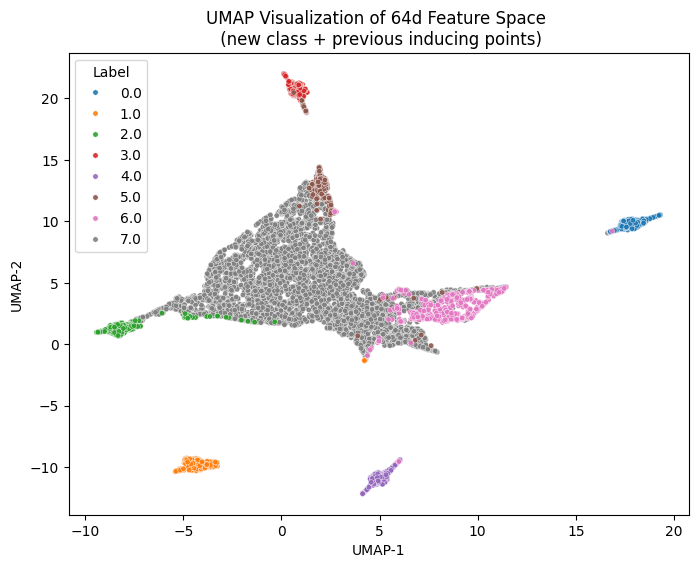

Train set size:  13063
Class 0: 965 samples
Class 1: 970 samples
Class 2: 969 samples
Class 3: 952 samples
Class 4: 970 samples
Class 5: 964 samples
Class 6: 1008 samples
Class 7: 6265 samples
13063
2
64
tensor(7)
run_task_i epochs: 100
num_epochs:  100


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/1623880221.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mode

Epoch [1/100], Loss: 5.7398, Accuracy: 50.13%
Test: Loss: 0.3417, Accuracy: 90.93%
Test: Loss: 0.3990, Accuracy: 86.92%
Test: Loss: 0.3538, Accuracy: 88.62%
Test: Loss: 1.7107, Accuracy: 77.26%
Epoch [2/100], Loss: 5.0405, Accuracy: 49.75%
Test: Loss: 0.3211, Accuracy: 91.89%
Test: Loss: 0.4346, Accuracy: 85.44%
Test: Loss: 0.3866, Accuracy: 87.34%
Test: Loss: 1.6048, Accuracy: 76.14%
Epoch [3/100], Loss: 4.4551, Accuracy: 47.25%
Test: Loss: 0.2793, Accuracy: 92.41%
Test: Loss: 0.4728, Accuracy: 79.74%
Test: Loss: 0.4214, Accuracy: 82.40%
Test: Loss: 1.4243, Accuracy: 71.83%
Epoch [4/100], Loss: 3.8967, Accuracy: 47.03%
Test: Loss: 0.2787, Accuracy: 91.92%
Test: Loss: 0.4227, Accuracy: 83.24%
Test: Loss: 0.3789, Accuracy: 85.41%
Test: Loss: 1.3126, Accuracy: 74.45%
Epoch [5/100], Loss: 3.6251, Accuracy: 49.72%
Test: Loss: 0.2861, Accuracy: 91.75%
Test: Loss: 0.3982, Accuracy: 85.94%
Test: Loss: 0.3580, Accuracy: 87.77%
Test: Loss: 1.2187, Accuracy: 76.51%
Epoch [6/100], Loss: 3.3156, A

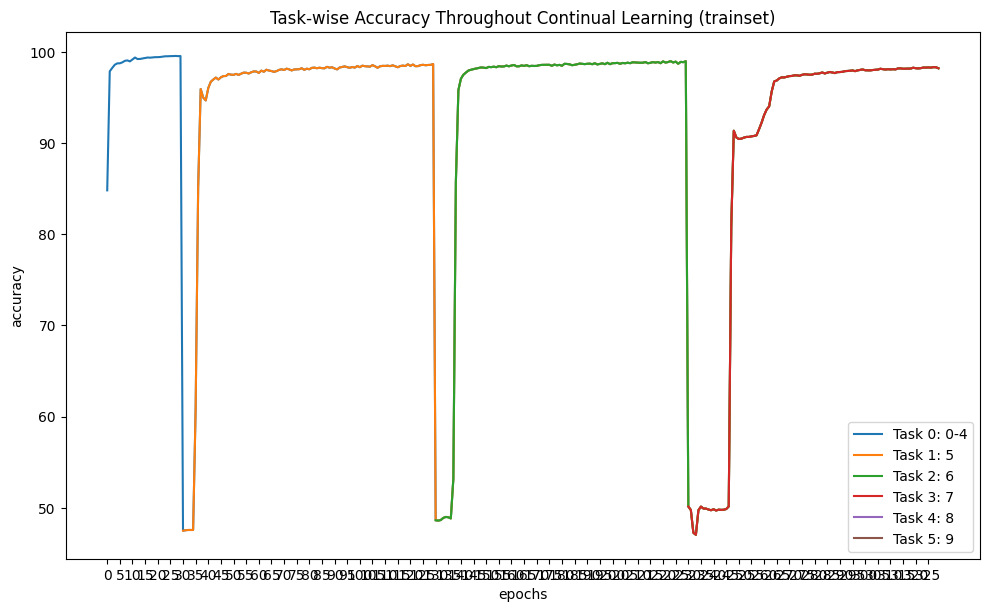

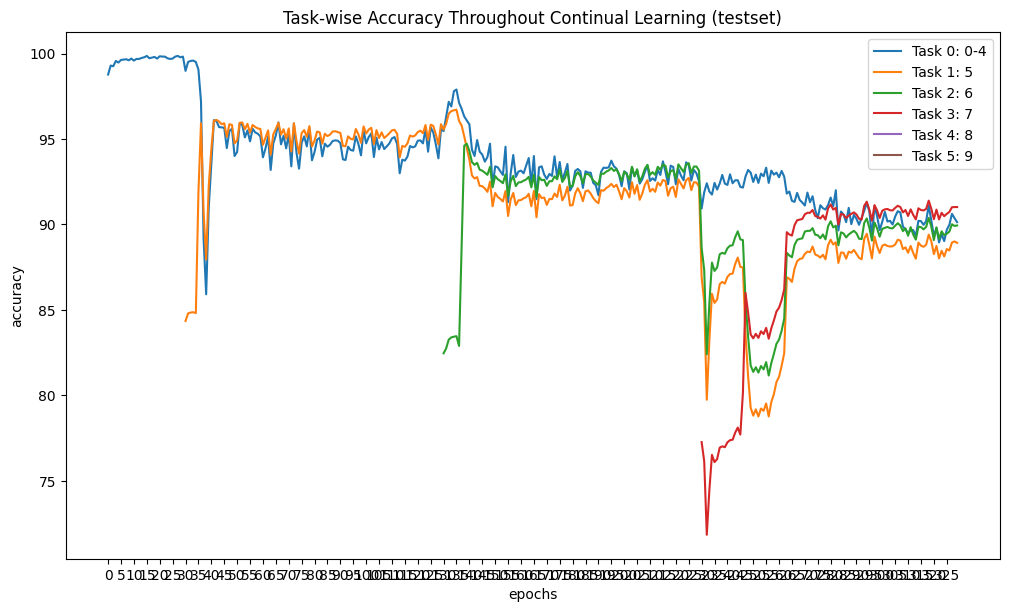

Open task dir:  /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-7


Loading required package: Matrix

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

This is gplite version 0.13.0


Directory already exists: /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-7/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f64 
[1] "n is greater than the number of rows in the data frame, using all rows:772"
[1] "n is greater than the number of rows in the data frame, using all rows:193"
[1] "class 0 training sample size (indclude noc_tr other classes): 822"
[1] "validation MSE for class0: 38.3611281046825"
[1] 469  64
[1] "n is greater than the number of rows in the data frame, using all rows:776"
[1] "n is greater than the number of rows in the data frame, using all rows:194"
[1] "class 1 training sample size (indclude noc_tr other classes): 826"
[1] "validation MSE for class1: 38.9753077839184"
[1] 938  64
[1] "n is greater than the number of rows in the data frame, using all rows:775"
[1] "n is greater than the number of rows in the data frame, using all rows:194"
[1] "class 2 training sample size (indclude noc_tr other classes): 825"
[1] 

Warning messages:
1: Removed 93 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 147 rows containing missing values or values outside the scale range
(`geom_line()`). 
3: Removed 234 rows containing missing values or values outside the scale range
(`geom_line()`). 
4: Removed 137 rows containing missing values or values outside the scale range
(`geom_line()`). 
5: Removed 320 rows containing missing values or values outside the scale range
(`geom_line()`). 
6: Removed 119 rows containing missing values or values outside the scale range
(`geom_line()`). 


[1] "Save Results"
null device 
          1 
------- Task 3 Finished -------


In [32]:
run_task_i(task_id=3, task='0-7', prev_task='0-6', epochs=100, use_indcpts=True)

## Task 4

Loading previous model from: 500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-7/model/f64_task0-7/MNIST_f64_task_0-7_net.pt
Test set size:  8991
Class 0: 980 samples
Class 1: 1135 samples
Class 2: 1032 samples
Class 3: 1010 samples
Class 4: 982 samples
Class 5: 892 samples
Class 6: 958 samples
Class 7: 1028 samples
Class 8: 974 samples


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/3322499310.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mod

Final new class feature space training dataset matrix size: torch.Size([5851, 75])
[INFO] Generated points saved to task0-7/indcpts_generated_points.csv


/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


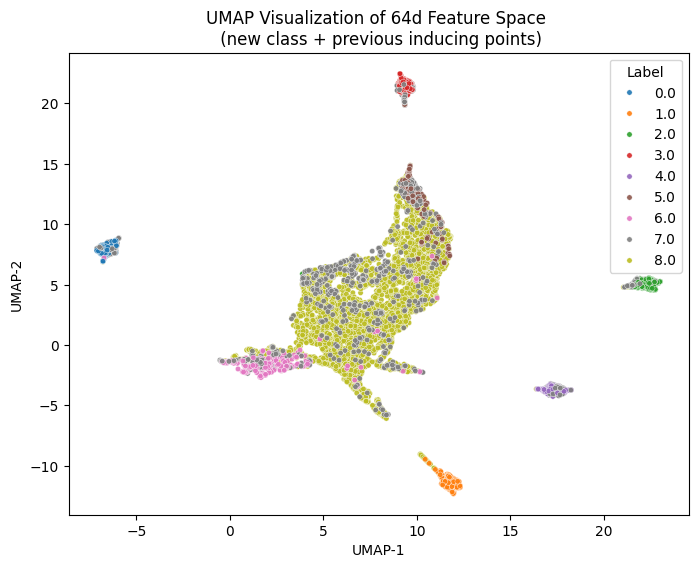

Train set size:  13618
Class 0: 821 samples
Class 1: 967 samples
Class 2: 889 samples
Class 3: 867 samples
Class 4: 760 samples
Class 5: 731 samples
Class 6: 839 samples
Class 7: 1893 samples
Class 8: 5851 samples
13618
2
64
tensor(8)
run_task_i epochs: 100
num_epochs:  100


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/1623880221.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mode

Epoch [1/100], Loss: 6.6377, Accuracy: 44.85%
Test: Loss: 0.7359, Accuracy: 82.12%
Test: Loss: 0.8080, Accuracy: 78.96%
Test: Loss: 0.7726, Accuracy: 79.12%
Test: Loss: 0.7245, Accuracy: 79.83%
Test: Loss: 2.0438, Accuracy: 71.18%
Epoch [2/100], Loss: 4.5273, Accuracy: 44.98%
Test: Loss: 0.5165, Accuracy: 88.44%
Test: Loss: 0.6783, Accuracy: 75.63%
Test: Loss: 0.6735, Accuracy: 75.65%
Test: Loss: 0.6641, Accuracy: 78.61%
Test: Loss: 1.3519, Accuracy: 70.09%
Epoch [3/100], Loss: 3.1011, Accuracy: 44.32%
Test: Loss: 0.4887, Accuracy: 89.69%
Test: Loss: 0.6746, Accuracy: 76.44%
Test: Loss: 0.6652, Accuracy: 76.88%
Test: Loss: 0.6637, Accuracy: 79.69%
Test: Loss: 1.2152, Accuracy: 71.06%
Epoch [4/100], Loss: 2.7214, Accuracy: 44.79%
Test: Loss: 0.4327, Accuracy: 90.74%
Test: Loss: 0.6340, Accuracy: 77.33%
Test: Loss: 0.6281, Accuracy: 77.78%
Test: Loss: 0.6326, Accuracy: 80.45%
Test: Loss: 1.1162, Accuracy: 71.74%
Epoch [5/100], Loss: 2.4438, Accuracy: 44.93%
Test: Loss: 0.4212, Accuracy: 

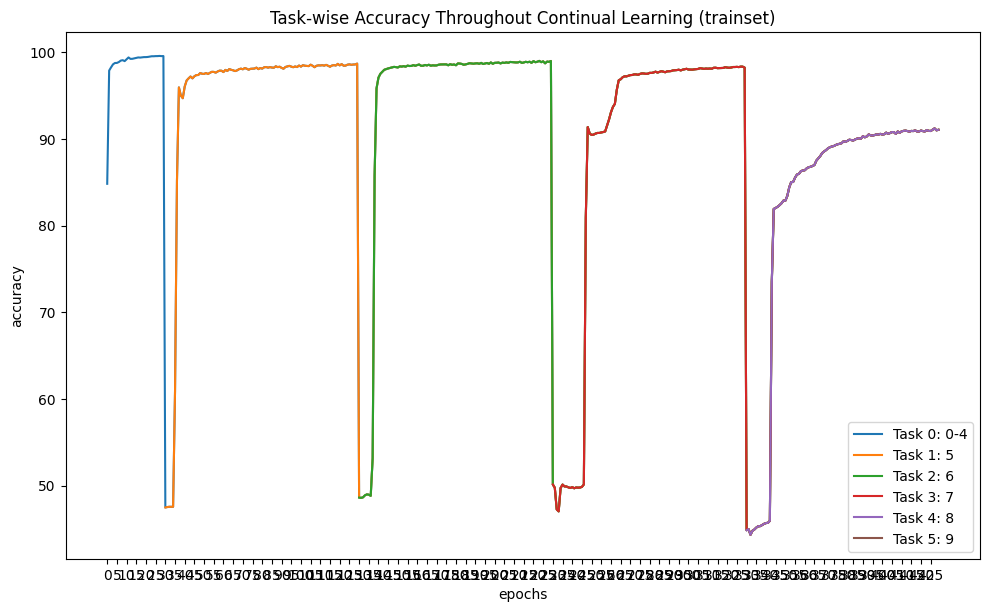

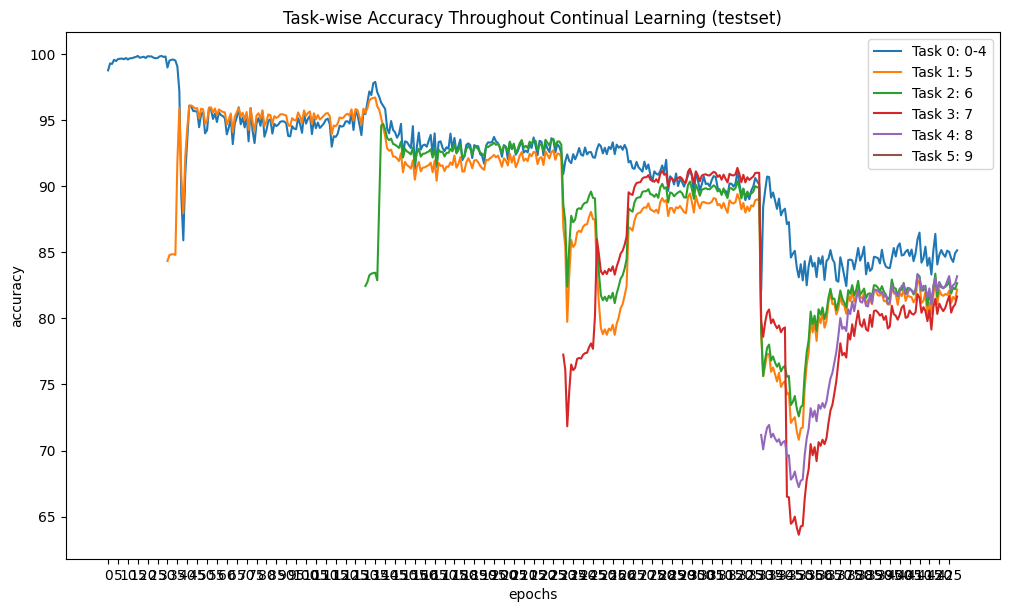

Open task dir:  /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-8


Loading required package: Matrix

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

This is gplite version 0.13.0


Directory already exists: /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-8/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f64 
[1] "n is greater than the number of rows in the data frame, using all rows:656"
[1] "n is greater than the number of rows in the data frame, using all rows:165"
[1] "class 0 training sample size (indclude noc_tr other classes): 706"
[1] "validation MSE for class0: 21.8764351667198"
[1] 464  64
[1] "n is greater than the number of rows in the data frame, using all rows:773"
[1] "n is greater than the number of rows in the data frame, using all rows:194"
[1] "class 1 training sample size (indclude noc_tr other classes): 823"
[1] "validation MSE for class1: 47.211409845357"
[1] 933  64
[1] "n is greater than the number of rows in the data frame, using all rows:711"
[1] "n is greater than the number of rows in the data frame, using all rows:178"
[1] "class 2 training sample size (indclude noc_tr other classes): 761"
[1] "

Warning message:
Removed 299 rows containing missing values or values outside the scale range
(`geom_line()`). 


[1] "Save Results"
null device 
          1 
------- Task 4 Finished -------


In [33]:
run_task_i(task_id=4, task='0-8', prev_task='0-7', epochs=100, use_indcpts=True)

## Task 5

Loading previous model from: 500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-8/model/f64_task0-8/MNIST_f64_task_0-8_net.pt
Test set size:  10000
Class 0: 980 samples
Class 1: 1135 samples
Class 2: 1032 samples
Class 3: 1010 samples
Class 4: 982 samples
Class 5: 892 samples
Class 6: 958 samples
Class 7: 1028 samples
Class 8: 974 samples
Class 9: 1009 samples


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/3322499310.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mod

Final new class feature space training dataset matrix size: torch.Size([5949, 75])
[INFO] Generated points saved to task0-8/indcpts_generated_points.csv


/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


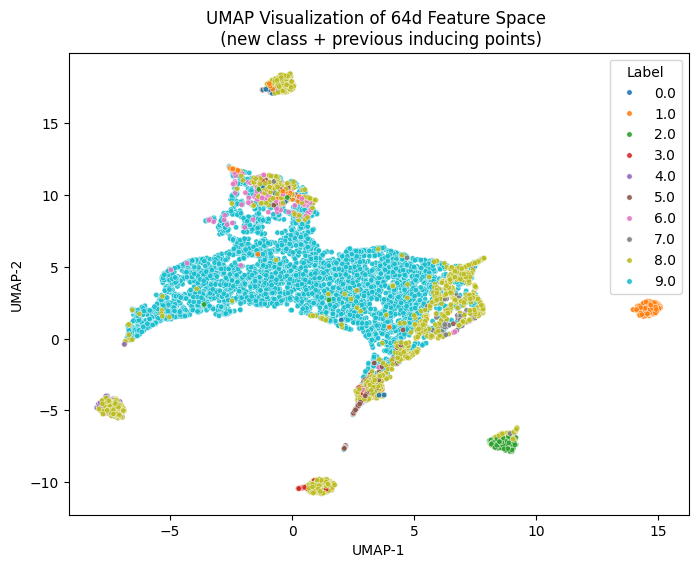

Train set size:  14668
Class 0: 598 samples
Class 1: 1062 samples
Class 2: 885 samples
Class 3: 573 samples
Class 4: 704 samples
Class 5: 796 samples
Class 6: 748 samples
Class 7: 584 samples
Class 8: 2769 samples
Class 9: 5949 samples
14668
2
64
tensor(9)
run_task_i epochs: 100
num_epochs:  100


/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/1623880221.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(previous_mode

Epoch [1/100], Loss: 6.7776, Accuracy: 34.68%
Test: Loss: 1.4073, Accuracy: 67.43%
Test: Loss: 1.4838, Accuracy: 65.11%
Test: Loss: 1.5343, Accuracy: 61.91%
Test: Loss: 1.7412, Accuracy: 54.51%
Test: Loss: 1.5604, Accuracy: 59.27%
Test: Loss: 2.7091, Accuracy: 53.29%
Epoch [2/100], Loss: 5.8367, Accuracy: 37.23%
Test: Loss: 1.3591, Accuracy: 66.88%
Test: Loss: 1.4248, Accuracy: 66.84%
Test: Loss: 1.4701, Accuracy: 63.04%
Test: Loss: 1.5421, Accuracy: 57.93%
Test: Loss: 1.3903, Accuracy: 61.94%
Test: Loss: 2.4729, Accuracy: 55.69%
Epoch [3/100], Loss: 5.4928, Accuracy: 38.39%
Test: Loss: 1.3553, Accuracy: 63.65%
Test: Loss: 1.3944, Accuracy: 64.90%
Test: Loss: 1.4596, Accuracy: 59.52%
Test: Loss: 1.4945, Accuracy: 56.17%
Test: Loss: 1.3525, Accuracy: 59.85%
Test: Loss: 2.3852, Accuracy: 53.81%
Epoch [4/100], Loss: 5.2226, Accuracy: 38.89%
Test: Loss: 1.1208, Accuracy: 69.94%
Test: Loss: 1.1784, Accuracy: 70.42%
Test: Loss: 1.2405, Accuracy: 65.52%
Test: Loss: 1.3051, Accuracy: 61.33%
Te

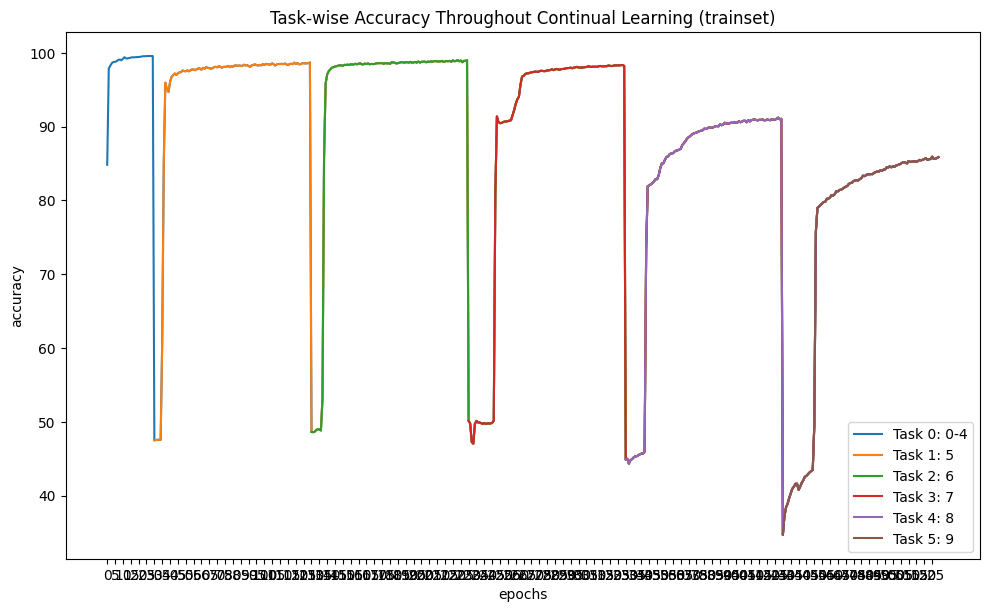

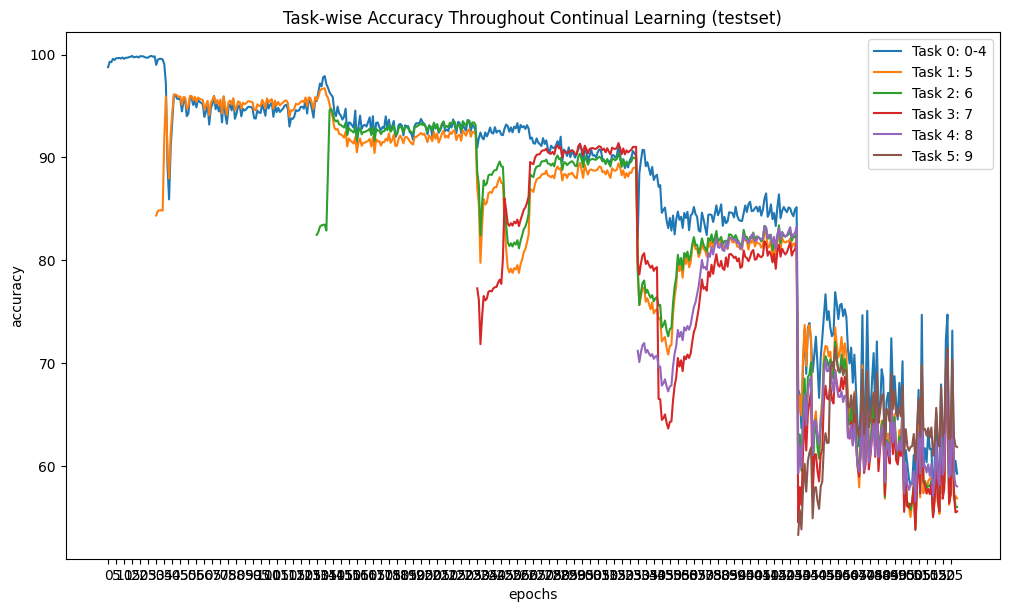

Open task dir:  /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-9


Loading required package: Matrix

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

This is gplite version 0.13.0


Directory already exists: /Users/hanliu/Desktop/CALM_all/500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-9/RData/indpts_Rdata_ntr1500_nts3000_noctr50_f64 
[1] "n is greater than the number of rows in the data frame, using all rows:478"
[1] "n is greater than the number of rows in the data frame, using all rows:120"
[1] "class 0 training sample size (indclude noc_tr other classes): 528"
[1] "validation MSE for class0: 238.403702647527"
[1] 452  64
[1] "n is greater than the number of rows in the data frame, using all rows:849"
[1] "n is greater than the number of rows in the data frame, using all rows:213"
[1] "class 1 training sample size (indclude noc_tr other classes): 899"
[1] "validation MSE for class1: 40.3371991978895"
[1] 924  64
[1] "n is greater than the number of rows in the data frame, using all rows:708"
[1] "n is greater than the number of rows in the data frame, using all rows:177"
[1] "class 2 training sample size (indclude noc_tr other classes): 758"
[1] 

Warning message:
In gp_optim(gp, x, y, tol = tol, tol_param = tol_param, maxiter = maxiter,  :
  Not all hyperparameters have reached convergence within tolerance tol_param = 0.100000. Try increasing the number of restarts, or reducing tol.


[1] "class 0 test data size:980"
[1] "class 1 test data size:1135"
[1] "class 2 test data size:1032"
[1] "class 3 test data size:1010"
[1] "class 4 test data size:982"
[1] "class 5 test data size:892"
[1] "class 6 test data size:958"
[1] "class 7 test data size:1028"
[1] "class 8 test data size:974"
[1] "class 9 test data size:1009"
[1] "Testset GPs:"
[1] "Total accuracy: 0.0484"
[1] "Confusion Matrix for Class:0"
                   Actual_Positive Actual_Negative
Predicted_Positive             465            6794
Predicted_Negative             515            2226
[1] "Accuracy: 0.2691"
[1] "Precision: 0.0640584102493456"
[1] "Recall for Class: 0.474489795918367"
[1] "F1 Score for Class: 0.112877776429178"
[1] "Confusion Matrix for Class:1"
                   Actual_Positive Actual_Negative
Predicted_Positive               0               0
Predicted_Negative            1135            8865
[1] "Accuracy: 0.8865"
[1] "Precision: NaN"
[1] "Recall for Class: 0"
[1] "F1 Score for Class: 0

Warning messages:
1: Removed 10 rows containing missing values or values outside the scale range
(`geom_bar()`). 
2: Removed 10 rows containing missing values or values outside the scale range
(`geom_bar()`). 
3: Removed 10 rows containing missing values or values outside the scale range
(`geom_bar()`). 
4: Removed 10 rows containing missing values or values outside the scale range
(`geom_bar()`). 
5: Removed 10 rows containing missing values or values outside the scale range
(`geom_bar()`). 


[1] "Save Results"
null device 
          1 
------- Task 5 Finished -------


In [34]:
run_task_i(task_id=5, task='0-9', prev_task='0-8', epochs=100, use_indcpts=True)

In [35]:
# task = '0-9'
# print(task_dir)

# # Output dirs
# parent_dir = os.getcwd()
# parent_dir = os.path.join(parent_dir, root_folder)
# task_dir = os.path.join(parent_dir, f'task{task}')
# out_dir = os.path.join(task_dir, f'out/f{f_size}_task{task}')
# model_dir = os.path.join(task_dir, f'model/f{f_size}_task{task}')
# create_dir_if_not_exists(out_dir)
# create_dir_if_not_exists(model_dir)

# train_data_file = os.path.join(out_dir, 'filtered_train_sftmx.csv')
# test_data_file = os.path.join(out_dir, 'test_sftmx.csv')
# print(train_data_file)

In [36]:

# cmd = [
#     "/usr/local/bin/Rscript",
#     "train_GP.R",
#     "-f", str(f_size),
#     "--data_tr", train_data_file,
#     "--data_ts", test_data_file,
#     "--directory", task_dir,
#     "--task", str(9)
# ]

# subprocess.run(cmd)

# Visualization

In [37]:
import umap
import seaborn as sns

/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/hanliu/miniconda3/envs/lab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


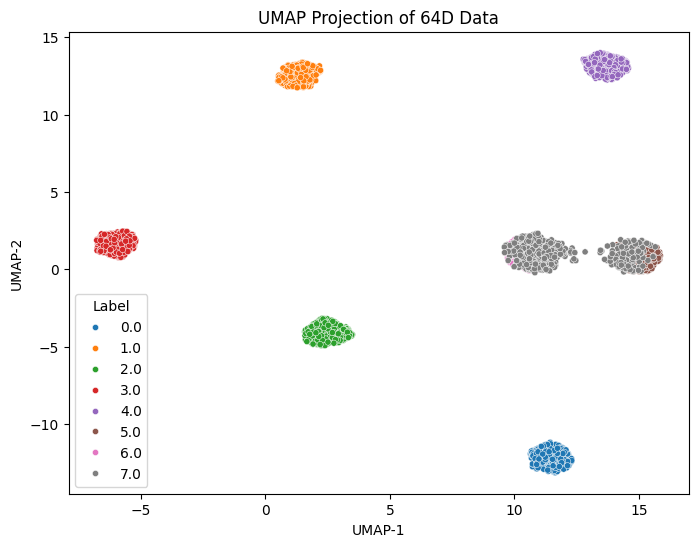

In [38]:
 # Load CSV file
df = pd.read_csv('500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-7/indcpts_generated_points.csv')  # Replace with your file path
X = df.iloc[:, :64].values   # First 64 columns as features
y = df.iloc[:, -1].values    # Last column as labels

# UMAP dimensionality reduction
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X)

# Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y, palette='tab10', s=20)
plt.title('UMAP Projection of 64D Data')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.legend(title='Label')
plt.savefig("umap_task0-8.png", dpi=300) 
plt.show()

/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/3124608307.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("500_Indpoint

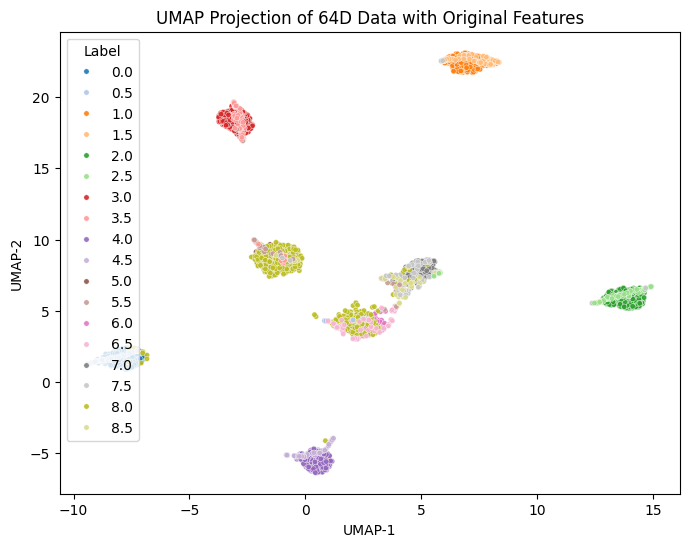

In [39]:
mnist_dataset, selected_indices, selected_labels = load_mnist_task(digits=[0, 1, 2, 3, 4, 5, 6, 7, 8], num_samples=500, is_train=True)
trloader = DataLoader(mnist_dataset, batch_size=train_batch_size, shuffle=True)

# get new class feature space 
model = ConvFeatNet(f_size=f_size).to(device)
model.load_state_dict(torch.load("500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-9/model/f64_task0-9/MNIST_f64_task_0-9_net.pt"))
model.eval()

original_data = torch.zeros(len(mnist_dataset), f_size+10+1)
features, scores, labels = extract_adapter_features_and_labels(model, trloader, device=device)

original_data[:, :f_size] = features
original_data[:, f_size:f_size+10] = scores 
original_data[:, -1] = labels + 0.5


 # Load CSV file
df = pd.read_csv('500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-8/indcpts_generated_points.csv')  # Replace with your file path
X = df.iloc[:, :f_size].values   # First 64 columns as features
y = df.iloc[:, -1].values    # Last column as labels

concate_X = np.concatenate((X, original_data[:, :f_size].numpy()), axis=0)
concate_y = np.concatenate((y, original_data[:, -1].numpy()), axis=0)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(concate_X)
# Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=concate_y, palette='tab20', s=15, alpha=0.9)
plt.title('UMAP Projection of 64D Data with Original Features')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.legend(title='Label')
plt.savefig("umap_task0-8_with_original.png", dpi=300)
plt.show()




/var/folders/79/t4ghgh4x7hb3gnf8q5qvr0lc0000gn/T/ipykernel_7178/1354359660.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("500_Indpoint

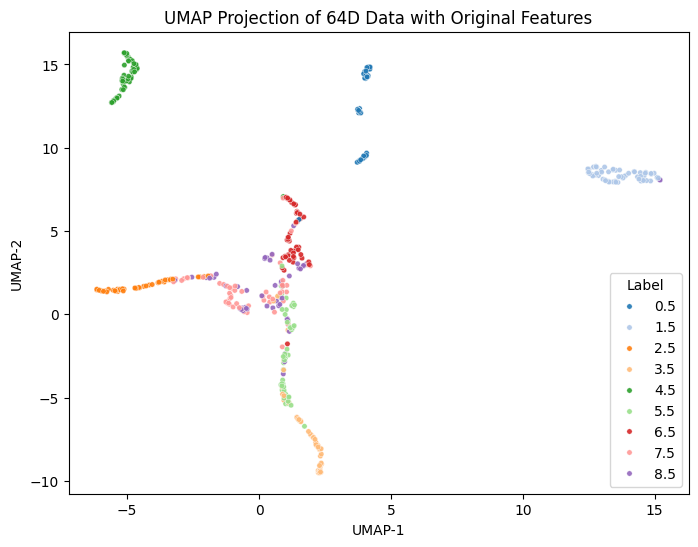

In [40]:
mnist_dataset, selected_indices, selected_labels = load_mnist_task(digits=[0, 1, 2, 3, 4, 5, 6, 7, 8], num_samples=500, is_train=True)
trloader = DataLoader(mnist_dataset, batch_size=train_batch_size, shuffle=True)

# get new class feature space 
model = ConvFeatNet(f_size=f_size).to(device)
model.load_state_dict(torch.load("500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-9/model/f64_task0-9/MNIST_f64_task_0-9_net.pt"))
model.eval()

original_data = torch.zeros(len(mnist_dataset), f_size+10+1)
features, scores, labels = extract_adapter_features_and_labels(model, trloader, device=device)

original_data[:, :f_size] = features
original_data[:, f_size:f_size+10] = scores 
original_data[:, -1] = labels + 0.5


 # Load CSV file
df = pd.read_csv('500_Indpoints_withGP_f64(generate500-GP-use-Nonfiltered)/task0-8/indcpts_generated_points.csv')  # Replace with your file path
X = df.iloc[:, :f_size].values   # First 64 columns as features
y = df.iloc[:, -1].values    # Last column as labels

concate_X = original_data[:, :f_size].numpy()
concate_y = original_data[:, -1].numpy()

# UMAP dimensionality reduction
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(concate_X)
# Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=concate_y, palette='tab20', s=15, alpha=0.9)
plt.title('UMAP Projection of 64D Data with Original Features')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.legend(title='Label')
plt.savefig("umap_task0-8-original.png", dpi=300)
plt.show()